In [1]:
# Import necessary libraries
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl
import torch

import pandas as pd
from itertools import accumulate

from tqdm import tqdm

import xarray as xr
import os
import sys

#from CODES.evolutionary_algorithm import process_depths,bootstrap_hof_uncertainty

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

# Internal modules
from ocean_inversion.config import (FOLDER_OUTPUT,FOLDER_NAME, MODEL_VP0,MODEL_RHO0,MODEL_EOFS,MODEL_COEF_HIST,MARGEM_COEF,
                                    DZ,DT,NT,F_PEAK,Z_MAX,ADD_NOISE,PERCENTAGE_NOISE,
                                    SEED, N_INV, NUM_PROCESS, POPULATION, CXPB, MUTPB, NGEN, TOURNSIZE,HOF_NUM,ETA_GENE)

from ocean_inversion.modeling import (
    mute_direct_arrival,normalize_data,
    calculate_synthetic_trace,ricker_wavelet,
    geometric_spreading_correction,bandpass_filter,
    crop_seismogram_by_depth,add_white_noise,apply_edge_taper
)

from ocean_inversion.evolutionary_algorithm import (
    bootstrap_hof_uncertainty
)



[ocean_inversion.config] Reading configuration file: /home/sysop/diogogit/NFH_inversion_seismic_oceanography/config_file.cnf


/home/sysop/Programs/anaconda3/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


# Text based on:

- Gallagher, K., & Sambridge, M. (1994). **Genetic algorithms: a powerful tool for large-scale nonlinear optimization problems**. Comput. Geosci., 20(7–8), 1229–1236.
- Fortin, F. A., Rainville, F. M., Gardner, M., Parizeau, M., and Gagné, C. **DEAP: Evolutionary Algorithms Made Easy**, Journal of Machine Learning Research, pp. 2171-2175, no 13, jul 2012.


## Ensure reproducible results by fixing seeds for numpy

In [2]:
rng = np.random.default_rng(SEED)

# Inputs and outputs

### Directory for saving model and other related stuffs: 

In [3]:
data_path = FOLDER_OUTPUT+FOLDER_NAME+'/DATA/'

### Directory for saving figures: 

In [4]:
figures_path = FOLDER_OUTPUT+FOLDER_NAME+'/FIGURES/'

---------

# **Comparison and final analysis:**

## Data Loading and Setup

In this section, we load the required datasets: the baseline velocity model, the EOF basis vectors, the density model ($\rho$), and the observed seismic traces. We also define the seismic configuration parameters such as peak frequency and sampling rate to generate the source wavelet.

In [5]:
# Load EOF basis and base models (example using xarray and numpy)
vp_base = np.load(MODEL_VP0)

rho_model = np.load(MODEL_RHO0)

eof_basis=np.load(MODEL_EOFS)

coef_hist=np.load(MODEL_COEF_HIST)

low = coef_hist.min(axis=1)
high = coef_hist.max(axis=1)

faixa = high - low
coef_mins = low - MARGEM_COEF * faixa
coef_maxs = high + MARGEM_COEF * faixa


# Load true velocity model
v_numpy = np.fromfile("/media/sysop/14f7ead0-5dcb-4557-a139-55dbb404d11a/diogoloc/dados_posdoc/NFH_inversion/modelo_inicial/sound_speed.bin", dtype=np.float32).reshape(2501, 5564)
vp_true = v_numpy.T[0]


# Observed data

In [6]:
device = torch.device("cpu")

ds = xr.open_zarr("/media/sysop/14f7ead0-5dcb-4557-a139-55dbb404d11a/diogoloc/dados_posdoc/NFH_inversion/dados_observados/ocean_data_synthetic.zarr")

subset = ds.amplitude.isel(shot=slice(0, 1),receiver=slice(0, 1)).load()

observed_data = torch.as_tensor(subset.values,dtype=torch.float32,device=device).numpy().squeeze()

In [7]:
s_obs = geometric_spreading_correction(observed_data, dt=DT, mode="cylindrical")

s_obs = mute_direct_arrival(
    trace=s_obs,
    offset=25,
    dt=DT,
    freq=F_PEAK,
    peak_time=1.5/F_PEAK
)

if ADD_NOISE: 
    s_obs = add_white_noise(s_obs, PERCENTAGE_NOISE)

s_obs = mute_direct_arrival(
    trace=s_obs,
    offset=25,
    dt=DT,
    freq=F_PEAK,
    peak_time=1.5/F_PEAK
)

s_obs = bandpass_filter(s_obs, dt=DT, f_peak=F_PEAK) 

s_obs = crop_seismogram_by_depth(seismogram=s_obs, base_model=vp_base, dz=DZ, dt=DT, z_max=Z_MAX)

s_norm = normalize_data(s_obs,method="trace_max")


# Inverted data

In [8]:
df_inversion = pd.read_feather(data_path+'inversion.feather')

In [9]:
df_inversion

,ssp,pop,misfit,ngen,inversion
0,"[[1527.3065409275985, 1527.403184897966, 1527....","[[1533.364473186672, 1533.4380277251537, 1533....","[2.9909087091413387, 2.5696210513273545, 2.360...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",1
1,"[[1527.139916151212, 1527.235995574314, 1527.4...","[[1532.3367316983201, 1532.4894695584458, 1532...","[3.0192382397343174, 2.602550033938187, 2.3942...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",2
2,"[[1526.8022808212133, 1526.8923270948458, 1527...","[[1518.2365529222689, 1518.3458335546998, 1518...","[3.084682715114475, 2.605337514704683, 2.41370...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",3
3,"[[1526.558846710048, 1526.6352055860357, 1526....","[[1530.6907689908837, 1530.847023157402, 1531....","[3.000660745613772, 2.6148241677167245, 2.4291...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",4
4,"[[1526.1385603208846, 1526.2382229760028, 1526...","[[1523.522434225868, 1523.626997499311, 1523.7...","[3.003262654097355, 2.5220464377574863, 2.3766...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",5
5,"[[1525.1312050784966, 1525.235614958776, 1525....","[[1530.2429025234783, 1530.4252069145493, 1530...","[3.026337545154247, 2.5713079536802126, 2.3964...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",6
6,"[[1524.1675734316696, 1524.2389396323222, 1524...","[[1527.0947730550727, 1527.1898180952444, 1527...","[3.01221072053066, 2.5441689570448216, 2.44285...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",7
7,"[[1543.4613962804815, 1543.574919413633, 1543....","[[1521.002783946369, 1521.092327632971, 1521.2...","[3.0195660425633597, 2.598546017649809, 2.4609...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",8
8,"[[1530.921987399552, 1531.065452758476, 1531.2...","[[1526.3504784470151, 1526.4104480421588, 1526...","[3.036239079118717, 2.6047693721003635, 2.3587...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",9
9,"[[1523.4002243819878, 1523.4903866284096, 1523...","[[1534.9932402667362, 1535.174129980199, 1535....","[2.959585636922686, 2.5592516943547543, 2.3760...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",10


In [10]:
population_first = np.concatenate(df_inversion['pop'].values)
ssp_hof = np.concatenate(df_inversion['ssp'].values).tolist()


# Bootstrap of Hall of Fame solutions – Predicted Data

To assess parameter uncertainty, we applied a bootstrap approach to the best-performing solutions stored in the *hall of fame (HOF)* across multiple independent inversions. The HOF ensemble contains the lowest-misfit models identified by the evolutionary algorithm, representing the most probable solutions given the observed data.


- *Hall of fame (HOF)*: the best individual that ever lived in the population during the evolution. It is lexicographically sorted at all time so that the first element of the hall of fame is the individual that has the best first fitness value ever seen, according to the weights provided to the fitness at creation time.

## Methodology

#### Bootstrap Resampling:
- We resampled the HOF ensemble with replacement, randomly selecting subsets of solutions to compute statistical properties such as mean, median, and confidence intervals. This approach captures variability in the optimized parameters (vs and thickness).

#### Uncertainty and Bias Reduction:
- Bootstrapping allows estimation of parameter uncertainty without assuming a theoretical distribution, which is especially useful for nonlinear inverse problems. It also reduces bias in estimators by approximating the true sampling distribution, yielding more robust parameter estimates.

In [11]:
dic_bootstrap_results = bootstrap_hof_uncertainty(ssp_hof,rng=rng, n_iterations=1000, ci_percentiles=[2.5, 97.5])

In [12]:
dic_bootstrap_results.keys()

dict_keys(['mean_ssp', 'std_ssp', 'ci_lower_ssp', 'ci_upper_ssp', 'bootstrap_distribution_ssp'])

In [13]:
df_bootstrap_results = pd.DataFrame(dic_bootstrap_results)

In [14]:
df_bootstrap_results

,mean_ssp,std_ssp,ci_lower_ssp,ci_upper_ssp,bootstrap_distribution_ssp
0,"[1526.7685785975768, 1526.8650204224875, 1527....","[0.0961202371851469, 0.0967812965630316, 0.097...","[1526.5730629910825, 1526.668242723518, 1526.8...","[1526.9546838021793, 1527.0524740968438, 1527....","[[1526.7299525153596, 1526.825096088578, 1527...."


In [15]:
df_bootstrap_results.bootstrap_distribution_ssp.values[0].shape

(1000, 201)

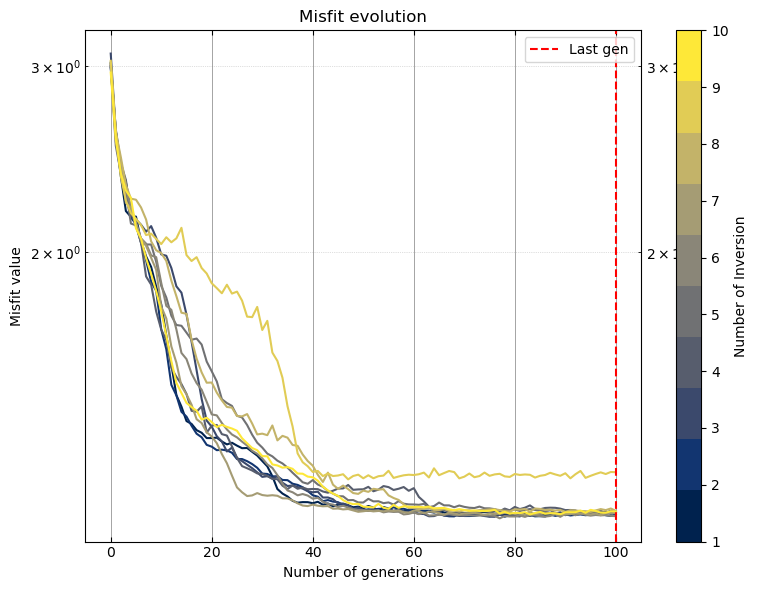

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

# One color per survey
norm = plt.Normalize(vmin=df_inversion['inversion'].values.min(), vmax=df_inversion['inversion'].values.max())


cmap = plt.get_cmap('cividis', len(df_inversion['inversion'].values))

for dativ in df_inversion.iterrows():
    color = cmap(norm(dativ[1]['inversion']))
    ax.semilogy(dativ[1]['ngen'], dativ[1]['misfit'], '-',color=color)
        
ax.set_xlabel('Number of generations')
ax.set_ylabel('Misfit value')
ax.axvline(x=len(dativ[1]['ngen'])-1, color='red', linestyle='--', label='Last gen')
ax.legend(loc='upper right')
ax.grid(True, which='both')
ax.tick_params(axis='both', which='both', direction='in',top=True, bottom=True, left=True, right=True,labelbottom=True, labeltop=False, labelleft=True,labelright=True)
ax.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
ax.grid(which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
ax.set_title('Misfit evolution')

# ScalarMappable to colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Colorbar
cbar = plt.colorbar(sm, ax=ax, ticks=df_inversion['inversion'].values)
cbar.set_label("Number of Inversion")
plt.tight_layout()

fig.savefig(figures_path+FOLDER_NAME+'_model_misfit_evolution.png', dpi=300)

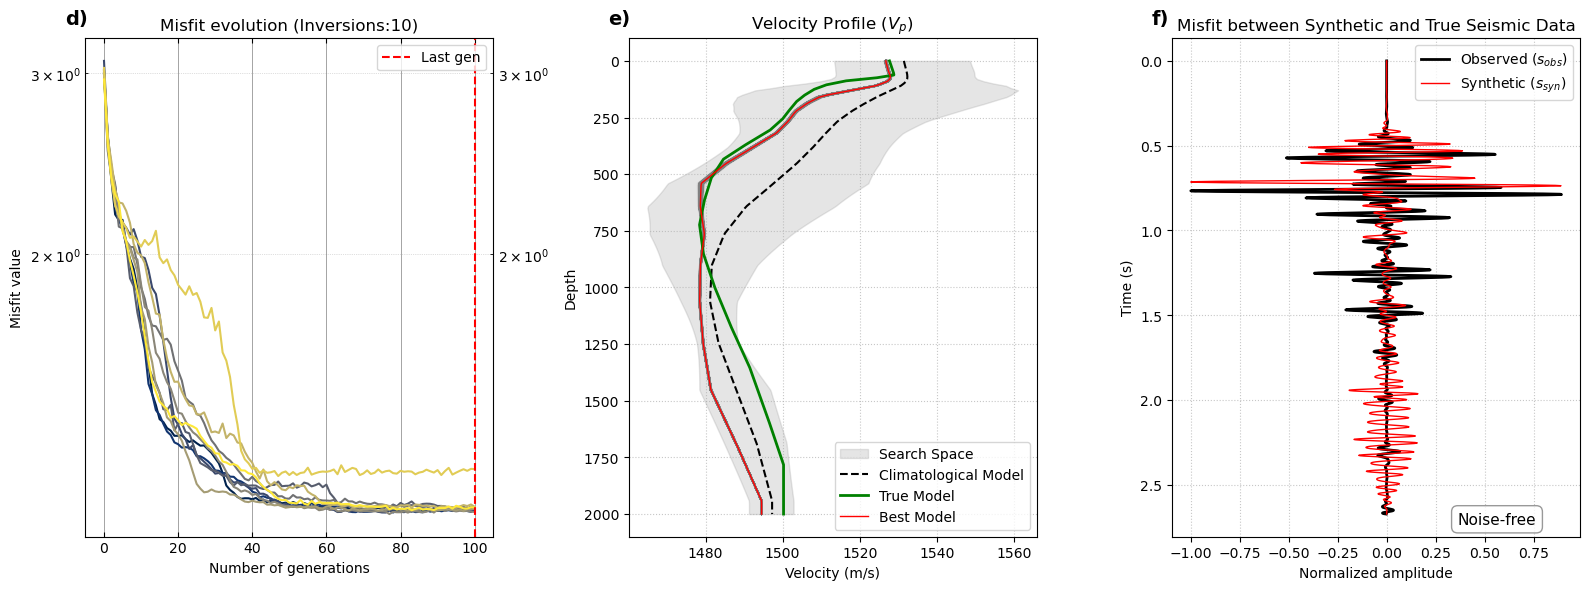

In [17]:
# ==========================================
# 3. PLOTTING
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(16, 6))


# --- PLOT 1: Convergence Curve ---

# One color per survey/run
norm = plt.Normalize(vmin=df_inversion['inversion'].values.min(), vmax=df_inversion['inversion'].values.max())

cmap = plt.get_cmap('cividis', len(df_inversion['inversion'].values))

# Loop over each inversion run and plot its misfit evolution on a log scale
for dativ in df_inversion.iterrows():
    color = cmap(norm(dativ[1]['inversion']))
    axs[0].semilogy(dativ[1]['ngen'], dativ[1]['misfit'], '-', color=color)

axs[0].set_xlabel('Number of generations')
axs[0].set_ylabel('Misfit value')
# Mark the last generation with a vertical dashed line
axs[0].axvline(x=len(dativ[1]['ngen'])-1, color='red', linestyle='--', label='Last gen')
axs[0].legend(loc='upper right')
axs[0].grid(True, which='both')
axs[0].tick_params(axis='both', which='both', direction='in', top=True, bottom=True, left=True, right=True,
                    labelbottom=True, labeltop=False, labelleft=True, labelright=True)
axs[0].grid(which='major', color='gray', linestyle='-', linewidth=0.5)
axs[0].grid(which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
axs[0].set_title('Misfit evolution'+' (Inversions:'+str(N_INV)+')')


# --- PLOT 2: Velocity Profiles (Vp) ---
# Building a generic depth axis (replace with your actual depth vector, e.g. z_depth)

# Concatenate all population arrays from the inversion runs
population_first = np.concatenate(df_inversion['pop'].values)

pop_mean = population_first.mean()
pop_std = population_first.std()
z_pop = np.linspace(0, Z_MAX, len(pop_mean))

# Shaded region representing the search space (mean +/- 3 standard deviations)
axs[1].fill_betweenx(z_pop, pop_mean - 3*pop_std, pop_mean + 3*pop_std,
                      color="gray", alpha=0.2, label="Search Space", zorder=-5)

z_base = np.linspace(0, Z_MAX, len(vp_base))
z_true = np.linspace(0, Z_MAX, len(vp_true))
vp_best = df_bootstrap_results.mean_ssp[0]

bootstrap_ssp_data = df_bootstrap_results.bootstrap_distribution_ssp.values[0]

axs[1].plot(bootstrap_ssp_data.T, z_pop, c='gray', alpha=0.02)

axs[1].plot(vp_base, z_base, 'k--', label='Climatological Model')
axs[1].plot(vp_true, z_true, 'g-', linewidth=2, label='True Model')

axs[1].plot(vp_best, z_pop, 'r-',lw=1, label='Best Model')

axs[1].set_title("Velocity Profile ($V_p$)")
axs[1].set_xlabel("Velocity (m/s)")
axs[1].set_ylabel("Depth")
axs[1].grid(True, linestyle=':', alpha=0.7)
axs[1].invert_yaxis()
axs[1].legend()

# --- PLOT 3: Seismic Traces ---

# 3. Define the density profile (Rho)
# Based on the setup function, rho_model appears to be constant across all tests
rho_best = rho_model

# 4. Estimate the synthetic trace

wavelet = ricker_wavelet(F_PEAK, DT)
s_syn_best = calculate_synthetic_trace(vp_profile=vp_best,
    rho_profile=rho_best,
    wavelet=wavelet,
    dz=DZ,
    dt=DT,
    nt=NT)

# Mute the direct arrival, apply bandpass filtering, crop by depth, and taper the edges
s_syn_best_mute = mute_direct_arrival(trace=s_syn_best, offset=25, dt=DT, freq=F_PEAK, peak_time=1.5/F_PEAK)

s_syn_best_mute = bandpass_filter(s_syn_best_mute, dt=DT, f_peak=F_PEAK)

s_syn_best_mute = crop_seismogram_by_depth(seismogram=s_syn_best_mute, base_model=vp_base, dz=DZ, dt=DT, z_max=Z_MAX)
s_syn_best_mute = apply_edge_taper(s_syn_best_mute)

# Normalize the synthetic trace by its maximum amplitude
s_syn_best_norm = normalize_data(s_syn_best_mute, method="trace_max")

t_obs = np.arange(len(s_norm))*DT
t_syn = np.arange(len(s_syn_best_norm))*DT
if ADD_NOISE:
    axs[2].text(
        0.7, 0.05, 
        f'Noise: {PERCENTAGE_NOISE:.0f} %', 
        transform=axs[2].transAxes, # Usa coordenadas relativas (0 a 1)
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.8) # Fundo branco para não misturar com as linhas
    )
else: 
    axs[2].text(
        0.7, 0.05, 
        'Noise-free', 
        transform=axs[2].transAxes, # Usa coordenadas relativas (0 a 1)
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.8) # Fundo branco para não misturar com as linhas
    )
axs[2].plot(s_norm, t_obs, 'k-', linewidth=2, label='Observed ($s_{obs}$)')
axs[2].plot(s_syn_best_norm, t_syn, 'r-', linewidth=1, label='Synthetic ($s_{syn}$)')
axs[2].invert_yaxis()  # Time increases downward (standard convention in seismics)
axs[2].set_title("Misfit between Synthetic and True Seismic Data")
axs[2].set_xlabel("Normalized amplitude")
axs[2].set_ylabel("Time (s)")
axs[2].grid(True, linestyle=':', alpha=0.7)
axs[2].legend()

labels = ['d)', 'e)', 'f)']

for i, ax in enumerate(axs):
    ax.text(
        -0.05, 1.02, # Posição: um pouco para a esquerda e para cima da quina do eixo
        labels[i], 
        transform=ax.transAxes, 
        fontsize=14, 
        fontweight='bold', 
        verticalalignment='bottom', 
        horizontalalignment='left'
    )

plt.tight_layout()